# Phase III: First ML Proof of Concept

### Team Members: Kaung Mo, Ian Menachery, Komal Jain, Sunithi Krishnan

### Ethical Considerations
Before we begin working with the data, some ethical concerns should be noted. The data that we are using for our project is from imdb Api which gives us information about movies like genre, directors, writers, actors, and most importantly, the movie's rating. However, this data does generate some level of concerns about ethicality.    

The first concern is about the manner in which IMDB generates ratings. IMDB collects ratings by allowing registered users to rate movies on a scale of 1 to 10. This could "review bombings" where the movie producers' competitors could arrange for a group of users to send a flurry of negative reviews towards a movie. Furthermore, both the movie's producers and the producers' competitors could pay a set of users or lobby users to leave positive or negative reviews on the movie which could influence the movie's rating. For example, a few years ago, Rotten Tomatoes, a similar site, was busted for allowing critics to pay users to positively influence a movie's rating.  Additionally, movies with controversial topics could be rated differently than uncontroversial movies on the site simply based on the movie's topic which adds a level of bias into the ratings. 

The other main concern is a lack of means to check the demographic breakdown of the ratings. This could lead to the over or under representation of certain groups which could lead to an inaccurate rating that is reflected as how the public views a movie.  

However, in regard to general ethical concerns, the api allows all users to be anonymous, so there is no personal data that can be revealed from the api which removes all of the more general ethical concerns. 

### Assumption Analysis

When using linear regression, there are a few important assumptions to keep in mind to make sure the model works properly.
1. The data points should be independent, meaning that one observation shouldn’t influence another.
2. There needs to be a linear relationship between the independent variables (predictors) and the dependent variable (target). If the relationship isn’t linear, the model might not give accurate predictions.
3. The model assumes homoscedasticity, which means that the spread of the residuals (the difference between actual and predicted values) should stay constant across all predicted values.
4. The normality assumption means that the residuals should follow a normal distribution.  

In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split

# Replace 'your_file.csv' with the path to your CSV file
file_path = 'movies_output_clean.csv'

# Load the CSV file into a Pandas DataFrame
df = pd.read_csv(file_path)

df_first = df[['Genre', 'RottenTomatoesScore (%)', 'BoxOfficeEarnings ($)', 'IMDbRating']]

df_drops = df_first.dropna()
# After dropping instances of we are left with 732 movies

display(df.head())
df_drops

,Title,Year,Rated,ReleaseDate,Runtime (min),Genre,Director,Writer,Actors,Plot,Language,Country,Awards,IMDRating (out of 10),RottenTomatoesScore (%),IMDbRating,IMDbVotes,BoxOfficeEarnings ($)
0,Venom: The Last Dance,2024.0,PG-13,2024-10-25,109.0,"Action, Adventure, Sci-Fi",Kelly Marcel,"Kelly Marcel, Tom Hardy","Tom Hardy, Juno Temple, Alanna Ubach",Eddie and Venom are on the run. Hunted by both...,English,"United States, United Kingdom, Mexico",NaN,NaN,41.0,NaN,NaN,NaN
1,Terrifier 3,2024.0,Not Rated,2024-10-11,125.0,Horror,Damien Leone,Damien Leone,"Lauren LaVera, David Howard Thornton, Antonell...",Art the Clown is set to unleash chaos on the u...,English,United States,NaN,6.7,77.0,6.7,18437.0,45670161.0
2,The Wild Robot,2024.0,PG,2024-09-27,102.0,"Animation, Sci-Fi",Chris Sanders,"Chris Sanders, Peter Brown","Lupita Nyong'o, Pedro Pascal, Kit Connor","After a shipwreck, an intelligent robot called...",English,"United States, Japan",3 wins & 2 nominations,8.3,98.0,8.3,80239.0,137913995.0
3,Deadpool,2016.0,R,2016-02-12,108.0,"Action, Comedy",Tim Miller,"Rhett Reese, Paul Wernick","Ryan Reynolds, Morena Baccarin, T.J. Miller",A wisecracking mercenary gets experimented on ...,English,United States,29 wins & 78 nominations,8.0,85.0,8.0,1174691.0,363070709.0
4,Smile 2,2024.0,R,2024-10-18,127.0,"Horror, Mystery, Thriller",Parker Finn,Parker Finn,"Naomi Scott, Rosemarie DeWitt, Lukas Gage","About to embark on a world tour, global pop se...",English,"United States, Canada",NaN,7.2,85.0,7.2,21791.0,41787385.0


,Genre,RottenTomatoesScore (%),BoxOfficeEarnings ($),IMDbRating
1,Horror,77.0,45670161.0,6.7
2,"Animation, Sci-Fi",98.0,137913995.0,8.3
3,"Action, Comedy",85.0,363070709.0,8.0
4,"Horror, Mystery, Thriller",85.0,41787385.0,7.2
5,"Drama, Horror",90.0,16235191.0,7.5
...,...,...,...,...
995,"Action, Comedy, Crime",60.0,186336279.0,6.5
996,"Action, Comedy, Crime",71.0,127440871.0,6.3
997,Comedy,47.0,72217396.0,6.9
998,"Action, Adventure, Family",49.0,93436322.0,6.4


In [5]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df_x = df_drops[['Genre', 'RottenTomatoesScore (%)', 'BoxOfficeEarnings ($)']].copy()
df_x['Genre'] = df_x['Genre'].str.split(',').str[0].str.strip()

df_x_encoded = pd.get_dummies(df_x, columns=['Genre'], prefix='Genre')

display(df_x_encoded)
# Target variable
y = df_drops['IMDbRating']

# Feature scaling
scaler = StandardScaler()
X = scaler.fit_transform(df_x_encoded)

# Train-test split
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.3, random_state=3)

# Model Training
model = LinearRegression()
model.fit(Xtrain, ytrain)

# Predictions
y_pred = model.predict(Xtest)

residuals = ytest - y_pred

# Evaluation
mse = mean_squared_error(ytest, y_pred)
r2 = r2_score(ytest, y_pred)

print(f"MSE: {mse}")
print(f"R²: {r2}")
print(residuals)

,RottenTomatoesScore (%),BoxOfficeEarnings ($),Genre_Action,Genre_Adventure,Genre_Animation,Genre_Biography,Genre_Comedy,Genre_Crime,Genre_Drama,Genre_Fantasy,Genre_Horror,Genre_Mystery,Genre_Thriller
1,77.0,45670161.0,False,False,False,False,False,False,False,False,True,False,False
2,98.0,137913995.0,False,False,True,False,False,False,False,False,False,False,False
3,85.0,363070709.0,True,False,False,False,False,False,False,False,False,False,False
4,85.0,41787385.0,False,False,False,False,False,False,False,False,True,False,False
5,90.0,16235191.0,False,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,60.0,186336279.0,True,False,False,False,False,False,False,False,False,False,False
996,71.0,127440871.0,True,False,False,False,False,False,False,False,False,False,False
997,47.0,72217396.0,False,False,False,False,True,False,False,False,False,False,False
998,49.0,93436322.0,True,False,False,False,False,False,False,False,False,False,False


MSE: 0.31517149698493935
R²: 0.587769385605992
113    0.029939
441   -0.279045
984   -0.001702
337    0.346345
756   -0.659905
         ...   
490    0.485603
731    0.246150
256    0.745955
892    0.447908
729   -0.466545
Name: IMDbRating, Length: 238, dtype: float64


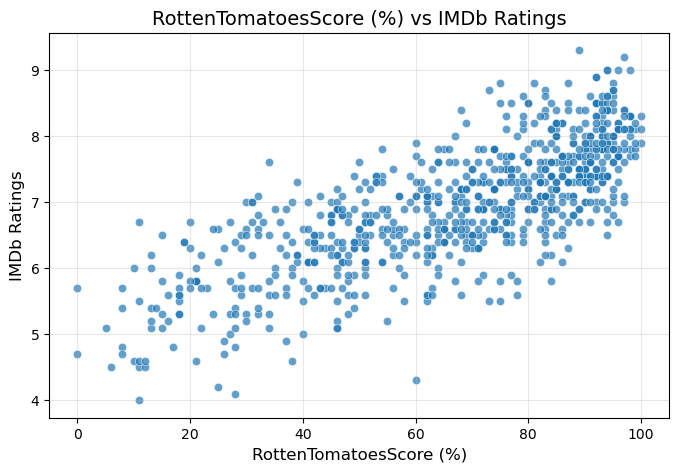

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatterplot for RottenTomatoesScore (%) vs IMDb ratings
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df_drops['RottenTomatoesScore (%)'], y=df_drops['IMDbRating'], alpha=0.7)
plt.title("RottenTomatoesScore (%) vs IMDb Ratings", fontsize=14)
plt.xlabel("RottenTomatoesScore (%)", fontsize=12)
plt.ylabel("IMDb Ratings", fontsize=12)
plt.grid(alpha=0.3)
plt.show()

The relationship between Rotten Tomatoes Score and IMDb Ratings appears to be linear with minor deviations.

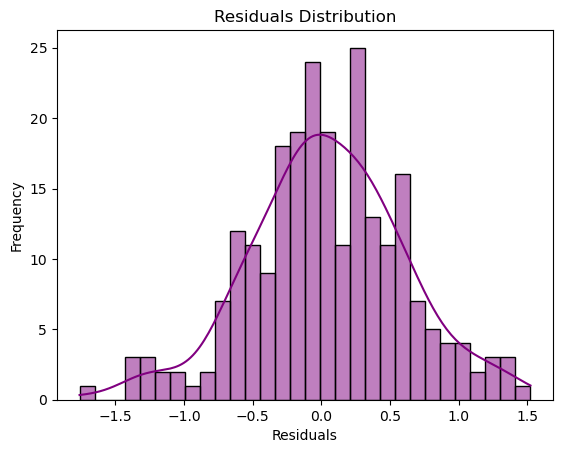

In [15]:
#Residual distribution to check normality
sns.histplot(residuals, kde=True, color="purple", bins=30)
plt.title("Residuals Distribution")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

The residuals exhibit a near-normal distribution, satisfying the normality assumption for regression analysis

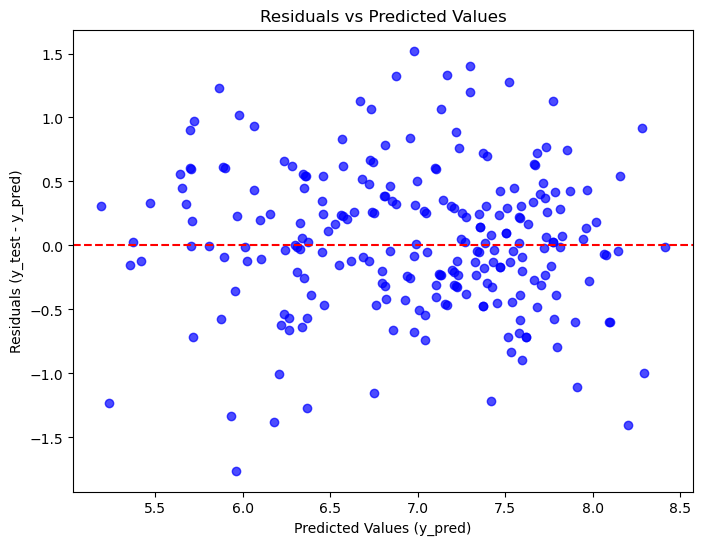

In [18]:
# Scatter plot: Predicted values vs. Residuals (Homoscedasticity check)
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.7, color="blue")
plt.axhline(y=0, color='red', linestyle='--')
plt.title("Residuals vs Predicted Values")
plt.xlabel("Predicted Values (y_pred)")
plt.ylabel("Residuals (y_test - y_pred)")
plt.show()

The residuals in the plot appear to be randomly scattered around the zero line with no clear pattern or increasing variance, suggesting that the assumption of homoscedasticity